# Notebook 1 — Klasifikasi Gaya Belajar Mahasiswa
**Mata Kuliah:** Pembelajaran Mesin — UAS Genap T.A. 2025/2026  
**Program Studi:** Informatika, Universitas Atma Jaya Yogyakarta  
**Dosen:** Yohanes Sigit Purnomo, Ph.D. & Theresia Devi Indriasari, Ph.D.

---
**Tujuan:** Membangun model klasifikasi untuk memprediksi kategori gaya belajar mahasiswa (Visual, Auditory, ReadWrite, Kinesthetic) berdasarkan jawaban survei menggunakan pendekatan VARK.


## 1. Import Library

In [1]:
# ── Library standar & data manipulation ──────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.pipeline            import Pipeline
from sklearn.compose             import ColumnTransformer
from sklearn.preprocessing       import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute              import SimpleImputer

# ── Scikit-learn: Feature Selection ──────────────────────────────────────────
from sklearn.feature_selection   import SelectKBest, SelectPercentile, f_classif

# ── Scikit-learn: Model Split & Validation ────────────────────────────────────
from sklearn.model_selection     import (train_test_split, GridSearchCV,
                                         StratifiedKFold, cross_validate,
                                         cross_val_score)

# ── Scikit-learn: Classifier ──────────────────────────────────────────────────
from sklearn.linear_model        import LogisticRegression
from sklearn.neighbors           import KNeighborsClassifier
from sklearn.tree                import DecisionTreeClassifier
from sklearn.ensemble            import RandomForestClassifier

# ── Scikit-learn: Evaluasi ────────────────────────────────────────────────────
from sklearn.metrics             import (accuracy_score, precision_score,
                                         recall_score, f1_score,
                                         classification_report,
                                         ConfusionMatrixDisplay,
                                         confusion_matrix)

# ── Export model ──────────────────────────────────────────────────────────────
import joblib

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 99
print("✅ Semua library berhasil diimport.")
print(f"   RANDOM_STATE = {RANDOM_STATE}")


✅ Semua library berhasil diimport.
   RANDOM_STATE = 99


## 2. Data Loading
Dataset yang digunakan adalah hasil survei preferensi belajar, kebiasaan belajar, dan faktor akademik mahasiswa yang telah **dianonimkan** (kolom identitas dihapus).


In [2]:
# ── Baca file Excel ───────────────────────────────────────────────────────────
FILE_PATH = 'ANONIM_Survei Preferensi Belajar, Kebiasaan Belajar, dan Faktor Akademik Mahasiswa (Responses).xlsx'
df_raw = pd.read_excel(FILE_PATH)

# ── Shape ─────────────────────────────────────────────────────────────────────
print(f"Shape  : {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")


Shape  : 324 baris × 89 kolom


In [3]:
# ── Head ──────────────────────────────────────────────────────────────────────
df_raw.head(3)


,Timestamp,Pernyataan Persetujuan,Program studi,Semester saat ini,Jenis kelamin,Usia (tahun),Status tempat tinggal selama kuliah,Apakah Anda bekerja sambil kuliah?,Sumber pembiayaan utama kuliah saya saat ini adalah:,Rata-rata waktu belajar mandiri per hari di luar jam kuliah,...,"Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir,"Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?","Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E?"
0,2026-03-17 16:11:14.219,Saya BERSEDIA mengikuti survei ini secara suka...,Arsitektur,6,Perempuan,20.0,Kost/asrama,Tidak,"Orang tua / keluarga, Beasiswa sebagian",1–2 jam,...,3.0,3.0,3.0,3.0,4.0,3.0,3.20,2.80,Tidak,Tidak
1,2026-03-17 16:23:55.853,Saya BERSEDIA mengikuti survei ini secara suka...,informatika,6,Perempuan,21.0,Bersama orang tua,Tidak,"Orang tua / keluarga, Beasiswa penuh",2–3 jam,...,3.0,3.0,3.0,2.0,3.0,4.0,3.07,3.91,Tidak,Tidak
2,2026-03-17 16:31:47.507,Saya BERSEDIA mengikuti survei ini secara suka...,Informatika,6,Laki-laki,20.0,Bersama orang tua,Tidak,Orang tua / keluarga,Kurang dari 1 jam,...,4.0,4.0,3.0,4.0,4.0,4.0,3.51,3.51,Tidak,Tidak


In [4]:
# ── Info ──────────────────────────────────────────────────────────────────────
df_raw.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 89 columns):
 #   Column                                                                                                                         Non-Null Count  Dtype         
---  ------                                                                                                                         --------------  -----         
 0   Timestamp                                                                                                                      324 non-null    datetime64[ns]
 1   Pernyataan Persetujuan                                                                                                         324 non-null    object        
 2    Program studi                                                                                                                 323 non-null    object        
 3    Semester saat ini                                                         

In [5]:
# ── Statistik deskriptif (kolom numerik) ─────────────────────────────────────
df_raw.describe().round(2)


,Timestamp,Usia (tahun),Kualitas akses internet untuk belajar,Kehadiran perkuliahan saya selama satu semester terakhir secara umum,"Saya lebih mudah memahami materi jika disajikan dalam bentuk diagram, bagan, atau infografik.",Saya lebih mudah mengingat materi ketika dosen menggunakan slide yang jelas dan visual.,"Warna, simbol, atau penanda visual membantu saya memahami konsep.",Saya lebih suka membuat peta konsep atau mind map saat belajar.,Saya lebih cepat memahami penjelasan jika disertai ilustrasi atau video.,Saya lebih mudah memahami materi dengan mendengarkan penjelasan lisan dosen.,...,"Saat menemukan materi yang sulit, saya mencari penjelasan tertulis dari buku, modul, artikel, atau internet.","Saat menghafal konsep atau istilah, saya menuliskannya berulang kali agar lebih ingat.","Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir
count,324,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,...,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00
mean,2026-04-21 19:47:46.415814912,20.93,4.04,4.58,3.73,4.32,4.36,3.48,4.31,3.75,...,4.02,3.77,3.87,3.93,3.99,3.73,4.02,4.05,10.91,10.32
min,2026-03-17 16:11:14.219000,18.00,1.00,2.00,1.00,1.00,2.00,1.00,2.00,1.00,...,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,0.00
25%,2026-04-14 22:12:47.149500160,20.00,4.00,4.00,3.00,4.00,4.00,3.00,4.00,3.00,...,3.00,3.00,3.00,3.00,3.00,3.00,3.50,3.50,3.36,3.50
50%,2026-04-25 00:01:07.254500096,21.00,4.00,5.00,4.00,4.00,4.00,3.00,4.00,4.00,...,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,3.60,3.70
75%,2026-04-28 21:40:19.310249984,21.00,5.00,5.00,4.00,5.00,5.00,4.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,3.80,3.90
max,2026-05-02 14:11:52.871000,26.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,390.00,380.00
std,NaN,1.21,0.84,0.68,0.93,0.78,0.71,1.12,0.80,0.99,...,0.83,1.08,0.92,0.84,0.88,1.01,0.83,0.83,49.99,45.20


## 3. Exploratory Data Analysis (EDA)
Pada bagian ini kita menggali karakteristik dataset secara menyeluruh sebelum pemodelan.


In [6]:
# ── Ringkasan dasar ───────────────────────────────────────────────────────────
print(f"Jumlah data      : {df_raw.shape[0]}")
print(f"Jumlah kolom     : {df_raw.shape[1]}")
print()

# Hitung tipe data
dtype_summary = df_raw.dtypes.value_counts()
print("Tipe data:")
for dtype, count in dtype_summary.items():
    print(f"  {dtype}: {count} kolom")


Jumlah data      : 324
Jumlah kolom     : 89

Tipe data:
  float64: 77 kolom
  object: 11 kolom
  datetime64[ns]: 1 kolom


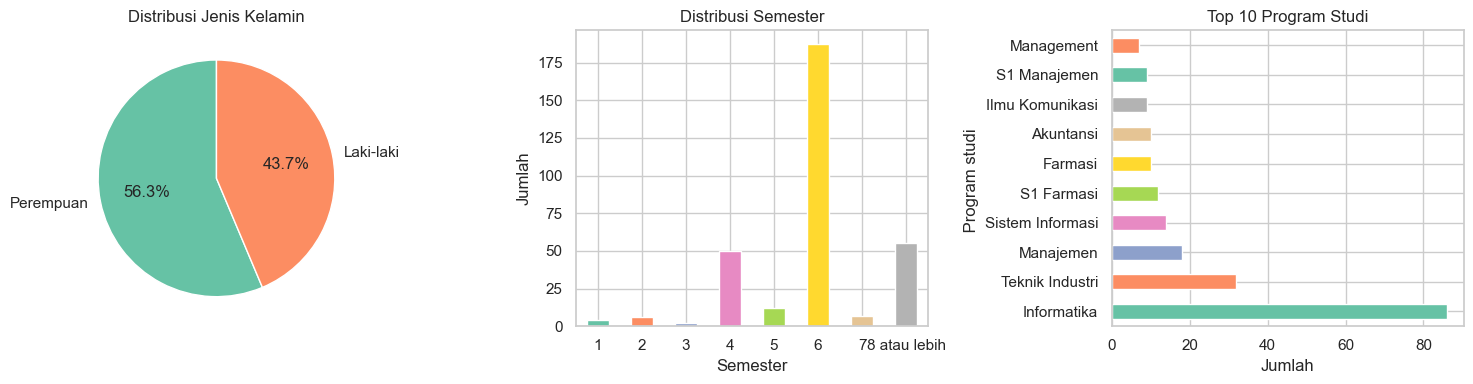

Interpretasi: Responden mayoritas perempuan, berasal dari semester 6, dan paling banyak berasal dari program studi Informatika.


In [7]:
# ── Distribusi jenis kelamin ──────────────────────────────────────────────────
col_gender = ' Jenis kelamin  '
col_prodi  = ' Program studi  '
col_smt    = ' Semester saat ini  '

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Jenis kelamin
gender_counts = df_raw[col_gender].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribusi Jenis Kelamin')

# Semester
smt_counts = df_raw[col_smt].value_counts()
smt_order = sorted(smt_counts.index, key=lambda x: int(str(x).split()[0]))
smt_counts = smt_counts.reindex(smt_order)
smt_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Distribusi Semester')
axes[1].set_xlabel('Semester'); axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)

# Prodi (top 10)
prodi_counts = df_raw[col_prodi].str.strip().str.title().value_counts().head(10)
prodi_counts.plot(kind='barh', ax=axes[2], color=sns.color_palette('Set2'))
axes[2].set_title('Top 10 Program Studi')
axes[2].set_xlabel('Jumlah')

plt.tight_layout()
plt.savefig('eda_demografi.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Responden mayoritas perempuan, berasal dari semester 6, "
      "dan paling banyak berasal dari program studi Informatika.")


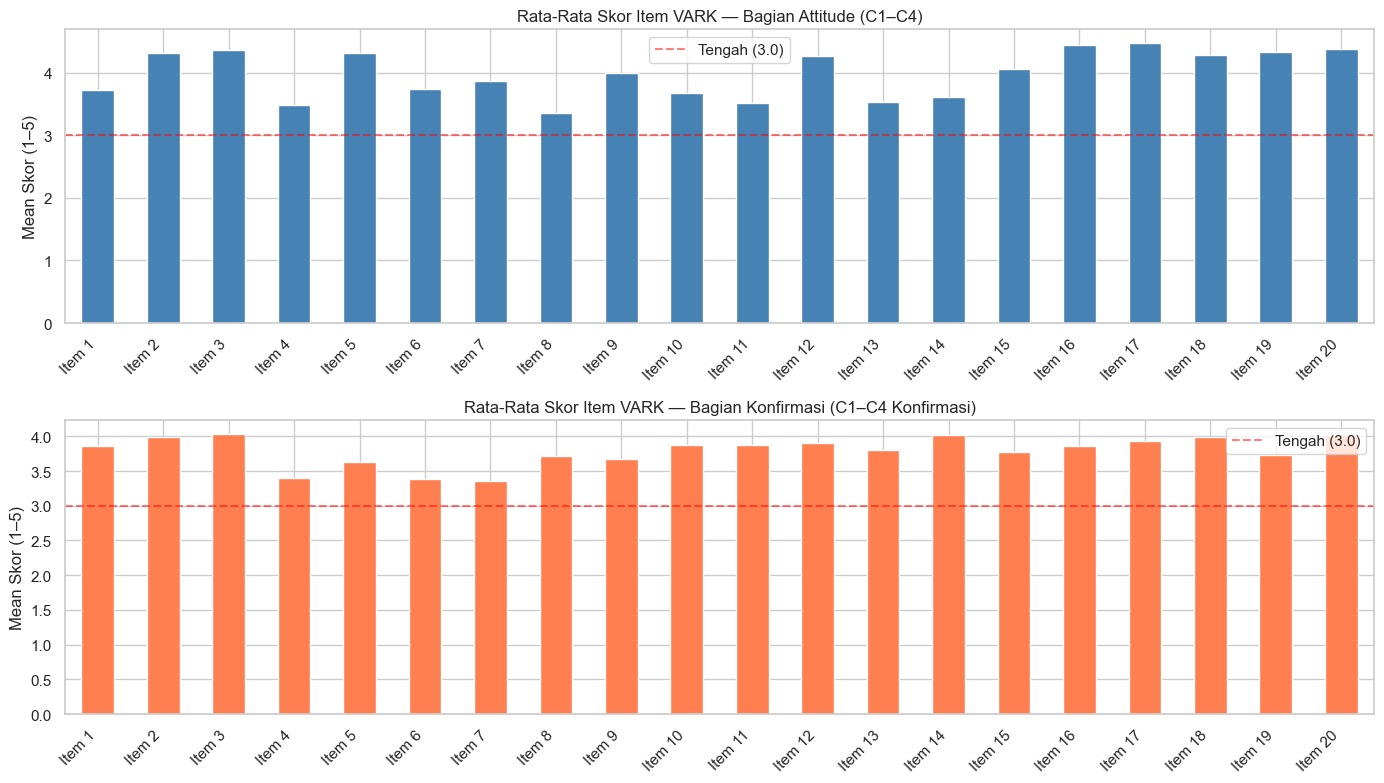

Interpretasi: Sebagian besar item VARK memiliki rata-rata di atas 3.0, menunjukkan kecenderungan responden menyetujui pernyataan-pernyataan gaya belajar.


In [8]:
# ── Distribusi item VARK (rata-rata skala 1-5) ────────────────────────────────
# Indeks kolom VARK attitude (C1-C4, cols 13-32) dan konfirmasi (cols 64-83)
vark_attitude_cols  = list(df_raw.columns[13:33])   # 20 item
vark_confirm_cols   = list(df_raw.columns[64:84])    # 20 item (termasuk dup di index 83 -> 84)

# Hanya ambil 20 kolom konfirmasi pertama yang valid (64-83)
vark_confirm_cols = list(df_raw.columns[64:84])

# Statistik rata-rata per item
means_att  = df_raw[vark_attitude_cols].mean()
means_conf = df_raw[vark_confirm_cols].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
means_att.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rata-Rata Skor Item VARK — Bagian Attitude (C1–C4)')
axes[0].set_ylabel('Mean Skor (1–5)')
axes[0].set_xticklabels([f'Item {i+1}' for i in range(20)], rotation=45, ha='right')
axes[0].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Tengah (3.0)')
axes[0].legend()

means_conf.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Rata-Rata Skor Item VARK — Bagian Konfirmasi (C1–C4 Konfirmasi)')
axes[1].set_ylabel('Mean Skor (1–5)')
axes[1].set_xticklabels([f'Item {i+1}' for i in range(20)], rotation=45, ha='right')
axes[1].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Tengah (3.0)')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_vark_items.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Sebagian besar item VARK memiliki rata-rata di atas 3.0, "
      "menunjukkan kecenderungan responden menyetujui pernyataan-pernyataan gaya belajar.")


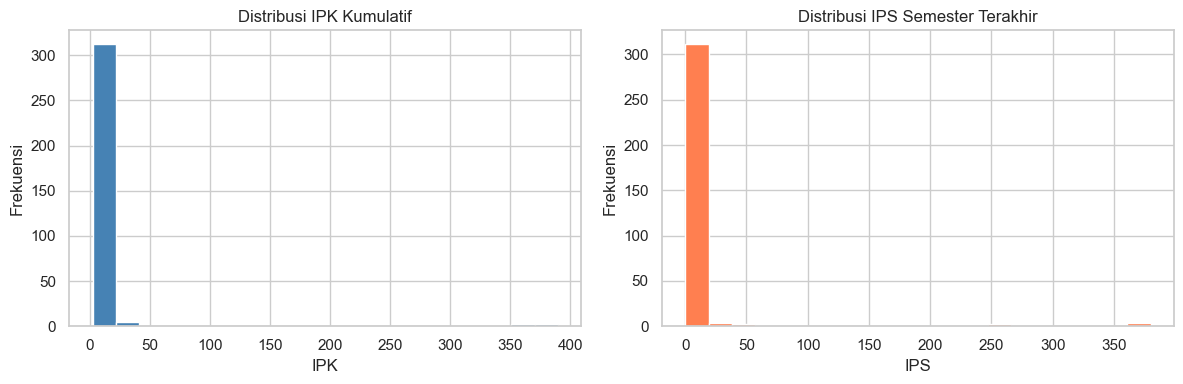

Interpretasi: Distribusi IPK cenderung right-skewed dengan puncak sekitar 3.0–3.7, mencerminkan performa akademik yang beragam di antara responden.


In [9]:
# ── Distribusi IPK dan IPS ────────────────────────────────────────────────────
col_ipk = '  IPK kumulatif saat ini  '
col_ips = ' IPS semester terakhir  '

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw[col_ipk].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi IPK Kumulatif')
axes[0].set_xlabel('IPK'); axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_raw[col_ips].dropna(), bins=20, color='coral', edgecolor='white')
axes[1].set_title('Distribusi IPS Semester Terakhir')
axes[1].set_xlabel('IPS'); axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_ipk_ips.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Distribusi IPK cenderung right-skewed dengan puncak sekitar 3.0–3.7, "
      "mencerminkan performa akademik yang beragam di antara responden.")


## 4. Data Checking
Pemeriksaan kualitas data: missing value, NaN, empty string, duplikasi, dan outlier.


In [10]:
# ── Missing Value per kolom ───────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
print(f"Kolom dengan missing value: {len(missing_df)}")
display(missing_df.head(20))


Kolom dengan missing value: 87


,Missing,Persen (%)
Program studi,1,0.31
Semester saat ini,1,0.31
Jenis kelamin,1,0.31
Usia (tahun),1,0.31
Status tempat tinggal selama kuliah,1,0.31
Apakah Anda bekerja sambil kuliah?,1,0.31
Sumber pembiayaan utama kuliah saya saat ini adalah:,1,0.31
Rata-rata waktu belajar mandiri per hari di luar jam kuliah,1,0.31
Perangkat utama yang digunakan untuk belajar,1,0.31
Kualitas akses internet untuk belajar,1,0.31


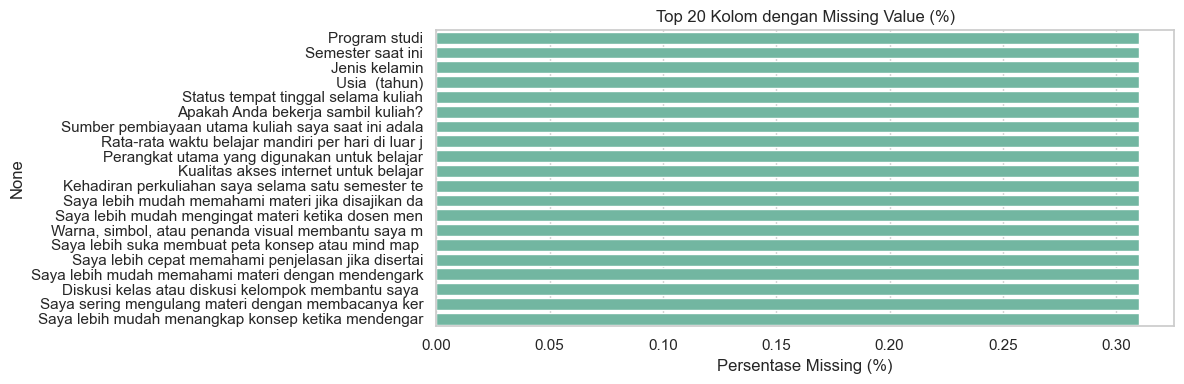

Interpretasi: Hampir semua missing value berasal dari 1 baris yang sama (baris responden yang tidak menyelesaikan survei). Persentase missing sangat kecil (~0.31%), sehingga baris tersebut dapat dihapus.


In [11]:
# ── Visualisasi Missing Value ─────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
missing_df_top = missing_df.head(20)
sns.barplot(x=missing_df_top['Persen (%)'], y=missing_df_top.index.str.strip().str[:50])
plt.title('Top 20 Kolom dengan Missing Value (%)')
plt.xlabel('Persentase Missing (%)')
plt.tight_layout()
plt.savefig('check_missing.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Hampir semua missing value berasal dari 1 baris yang sama (baris responden "
      "yang tidak menyelesaikan survei). Persentase missing sangat kecil (~0.31%), "
      "sehingga baris tersebut dapat dihapus.")


In [12]:
# ── Empty String ──────────────────────────────────────────────────────────────
obj_cols = df_raw.select_dtypes(include='object').columns
empty_str = {}
for c in obj_cols:
    n = (df_raw[c].astype(str).str.strip() == '').sum()
    if n > 0:
        empty_str[c] = n
print("Kolom dengan empty string:", empty_str if empty_str else "Tidak ada")


Kolom dengan empty string: Tidak ada


In [13]:
# ── Duplikasi ──────────────────────────────────────────────────────────────────
dup_count = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat: {dup_count}")


Jumlah baris duplikat: 0


In [14]:
# ── Outlier (IQR method) pada kolom Likert 1-5 ───────────────────────────────
likert_cols = list(df_raw.columns[13:33]) + list(df_raw.columns[64:84])
outlier_summary = []
for c in likert_cols:
    vals = df_raw[c].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((vals < Q1 - 1.5*IQR) | (vals > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_summary.append({'Kolom': c.strip()[:60], 'Outlier': n_out})

print(f"Jumlah kolom Likert dengan outlier (IQR): {len(outlier_summary)}")
if outlier_summary:
    display(pd.DataFrame(outlier_summary).head(10))
else:
    print("Tidak ada outlier signifikan pada skala Likert 1-5.")
print()
print("Catatan: Skala Likert 1-5 memiliki range terbatas sehingga outlier IQR")
print("umumnya tidak berdampak signifikan dan tidak perlu dihapus.")


Jumlah kolom Likert dengan outlier (IQR): 20


,Kolom,Outlier
0,Saya lebih mudah memahami materi jika disajika...,4
1,Saya lebih mudah mengingat materi ketika dosen...,8
2,"Warna, simbol, atau penanda visual membantu sa...",3
3,Saya lebih suka membuat peta konsep atau mind ...,13
4,Saya lebih cepat memahami penjelasan jika dise...,7
5,Saya sering mengulang materi dengan membacanya...,17
6,"Saya lebih suka belajar dari buku, modul, atau...",7
7,Saya lebih mudah memahami materi dengan mencat...,9
8,Saya suka membuat rangkuman tertulis setelah p...,11
9,Saya lebih nyaman menerima instruksi dalam ben...,9



Catatan: Skala Likert 1-5 memiliki range terbatas sehingga outlier IQR
umumnya tidak berdampak signifikan dan tidak perlu dihapus.


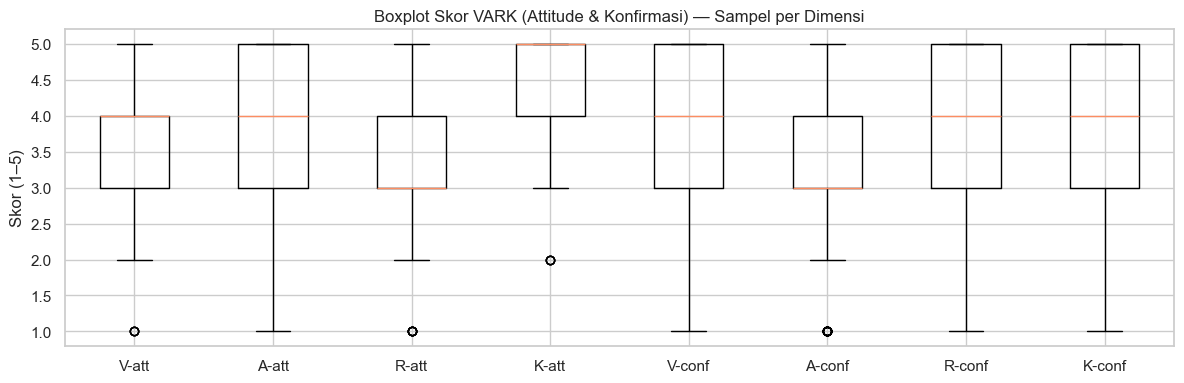

Interpretasi: Boxplot memperlihatkan distribusi terpusat di 3–4 untuk semua dimensi. Outlier (titik di luar whisker) sangat sedikit dan berada dalam range valid 1-5.


In [15]:
# ── Boxplot distribusi skor VARK ──────────────────────────────────────────────
# Ambil 8 kolom sample (4 attitude + 4 konfirmasi, satu per dimensi)
sample_cols = [df_raw.columns[13], df_raw.columns[18],
               df_raw.columns[23], df_raw.columns[28],
               df_raw.columns[64], df_raw.columns[69],
               df_raw.columns[74], df_raw.columns[79]]
labels = ['V-att','A-att','R-att','K-att','V-conf','A-conf','R-conf','K-conf']

fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot([df_raw[c].dropna() for c in sample_cols], labels=labels)
ax.set_title('Boxplot Skor VARK (Attitude & Konfirmasi) — Sampel per Dimensi')
ax.set_ylabel('Skor (1–5)')
plt.tight_layout()
plt.savefig('check_outlier_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Boxplot memperlihatkan distribusi terpusat di 3–4 untuk semua dimensi. "
      "Outlier (titik di luar whisker) sangat sedikit dan berada dalam range valid 1-5.")


## 5. Data Preparation
Langkah persiapan data sebelum pemodelan:
1. Hapus kolom tidak relevan (identitas, timestamp, pernyataan persetujuan)
2. Hapus kolom duplikat
3. Tangani missing value (hapus 1 baris yang semua nilainya kosong)
4. Tidak ada duplikasi baris
5. Reverse coding pada item balik (E5, F5) sesuai panduan survei


In [16]:
df = df_raw.copy()

# ── 5.1 Hapus kolom identitas & administrasi ──────────────────────────────────
# Kolom yang DIHAPUS:
# [0] Timestamp          — tidak relevan sebagai fitur, bukan informasi responden
# [1] Pernyataan Persetujuan — hanya berisi 1 nilai, tidak informatif
drop_cols = [df.columns[0], df.columns[1]]
df.drop(columns=drop_cols, inplace=True)
print(f"Setelah hapus kolom identitas: {df.shape}")


Setelah hapus kolom identitas: (324, 87)


In [17]:
# ── 5.2 Hapus kolom duplikat ──────────────────────────────────────────────────
# Kolom index-37 adalah duplikat D1.4 (terlihat dari nama ' 2' di akhir)
# Kolom index-84 adalah duplikat C4.5 konfirmasi (nama ' 2' di akhir)
# Setelah drop 2 kolom di atas, index bergeser -2
# Kolom duplikat D1.4: nama mengandung '  2'
# Kolom duplikat C4.5 conf: nama mengandung '  2'
dup_col_names = [c for c in df.columns if c.endswith(' 2') or c.endswith(' 2 ')]
print(f"Kolom duplikat ditemukan ({len(dup_col_names)}): {dup_col_names}")
df.drop(columns=dup_col_names, inplace=True)
print(f"Setelah hapus kolom duplikat: {df.shape}")


Kolom duplikat ditemukan (2): ['Saya jarang menunda mengerjakan tugas sampai mendekati tenggat waktu.  2', 'Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.  2']
Setelah hapus kolom duplikat: (324, 85)


In [18]:
# ── 5.3 Tangani missing value ─────────────────────────────────────────────────
# Hanya 1 baris yang memiliki missing value massif (hampir semua kolom kosong)
# → baris ini adalah responden yang tidak menyelesaikan survei, dihapus
n_before = len(df)
df.dropna(thresh=int(len(df.columns) * 0.5), inplace=True)  # hapus jika > 50% kolom kosong
df.reset_index(drop=True, inplace=True)
print(f"Baris dihapus karena missing > 50%: {n_before - len(df)}")
print(f"Baris tersisa: {len(df)}")
print(f"Missing value tersisa: {df.isnull().sum().sum()}")


Baris dihapus karena missing > 50%: 1
Baris tersisa: 323
Missing value tersisa: 0


In [19]:
# ── 5.4 Reverse coding ───────────────────────────────────────────────────────
# E5: 'Hambatan teknis seperti internet atau perangkat sering mengganggu proses belajar saya.'
# F5: 'Saya mudah terdistraksi oleh penggunaan perangkat digital saat sedang belajar.'
# Aturan: 1→5, 2→4, 3→3, 4→2, 5→1

def reverse_code(series):
    """Membalik skala Likert 1-5: nilai baru = 6 - nilai lama"""
    return 6 - series

# Cari kolom E5 dan F5
col_E5 = [c for c in df.columns if 'Hambatan teknis' in c][0]
col_F5 = [c for c in df.columns if 'terdistraksi' in c][0]

print(f"Reverse coding kolom:")
print(f"  E5: {col_E5.strip()[:70]}")
print(f"  F5: {col_F5.strip()[:70]}")

df[col_E5] = reverse_code(df[col_E5])
df[col_F5] = reverse_code(df[col_F5])

print(f"\n✅ Reverse coding selesai. Skor kini searah (tinggi = positif).")


Reverse coding kolom:
  E5: Hambatan teknis seperti internet atau perangkat sering mengganggu pros
  F5: Saya mudah terdistraksi oleh penggunaan perangkat digital saat sedang 

✅ Reverse coding selesai. Skor kini searah (tinggi = positif).


In [20]:
# ── 5.5 Standarisasi nilai kategorikal ───────────────────────────────────────
# Program studi: banyak variasi penulisan (huruf besar/kecil, spasi extra)
col_prodi = ' Program studi  '
df[col_prodi] = df[col_prodi].str.strip().str.title()
print(f"Nilai unik program studi: {df[col_prodi].nunique()}")
print(f"Shape akhir dataset bersih: {df.shape}")


Nilai unik program studi: 90
Shape akhir dataset bersih: (323, 85)


## 6. Feature Engineering — Membuat Target `LearningStyle`
Label gaya belajar dibuat berdasarkan panduan survei:
- **Visual** = rata-rata 10 item Visual (5 attitude + 5 konfirmasi)
- **Auditory** = rata-rata 10 item Auditory
- **ReadWrite** = rata-rata 10 item ReadWrite
- **Kinesthetic** = rata-rata 10 item Kinesthetic
- Label = dimensi dengan skor rata-rata tertinggi


In [21]:
# ── Definisi kolom VARK setelah drop kolom duplikat ──────────────────────────
# Kolom Likert berada pada indeks numerik; lebih aman pakai nama kolom

# VARK Attitude (pertanyaan preferensi, 5 item per dimensi, total 20)
visual_att    = [c for c in df.columns if any(k in c for k in [
    'diagram, bagan, atau infografik',
    'slide yang jelas dan visual',
    'Warna, simbol, atau penanda visual',
    'peta konsep atau mind map saat belajar',
    'ilustrasi atau video'])]

auditory_att  = [c for c in df.columns if any(k in c for k in [
    'mendengarkan penjelasan lisan dosen',
    'Diskusi kelas atau diskusi kelompok',
    'membacanya keras-keras atau menjelaskannya secara verbal',
    'mendengar contoh yang dijelaskan secara lisan',
    'rekaman audio atau penjelasan verbal membantu'])]

readwrite_att = [c for c in df.columns if any(k in c for k in [
    'buku, modul, atau artikel tertulis',
    'mencatat ulang poin-poin penting',
    'rangkuman tertulis setelah perkuliahan',
    'instruksi dalam bentuk tulisan daripada penjelasan lisan',
    'istilah atau konsep ketika menuliskannya'])]

kinesthetic_att = [c for c in df.columns if any(k in c for k in [
    'langsung mempraktikkannya',
    'Contoh kasus nyata membuat saya lebih cepat',
    'simulasi, eksperimen, atau demonstrasi',
    'mencoba sendiri langkah-langkahnya',
    'praktik daripada hanya membaca teori'])]

# VARK Konfirmasi (perilaku nyata saat belajar mandiri)
visual_conf    = [c for c in df.columns if any(k in c for k in [
    'slide, diagram, bagan, atau infografik untuk memahami',
    'mencari video pembelajaran untuk membantu',
    'highlight, warna, simbol, atau tanda khusus',
    'mind map, peta konsep, atau skema ringkas',
    'gambar, ilustrasi, tabel, atau tampilan visual lain'])]

auditory_conf  = [c for c in df.columns if any(k in c for k in [
    'mendengarkan ulang rekaman penjelasan atau audio',
    'suara keras agar lebih mudah memahami isi',
    'menjelaskan materi dengan lisan kepada diri sendiri',
    'berdiskusi dengan teman, baik secara langsung',
    'penjelasan berbentuk suara atau video yang menjelaskan materi secara verbal'])]

readwrite_conf = [c for c in df.columns if any(k in c for k in [
    'membaca ulang catatan kuliah, modul',
    'menulis ulang poin-poin penting dari materi',
    'rangkuman tertulis dengan bahasa saya sendiri',
    'penjelasan tertulis dari buku, modul, artikel, atau internet',
    'menuliskannya berulang kali agar lebih ingat'])]

kinesthetic_conf = [c for c in df.columns if any(k in c for k in [
    'latihan soal, tugas, atau kuis untuk memahami',
    'mencoba langsung langkah-langkah atau prosedur',
    'contoh kasus nyata agar lebih mudah memahami konsep',
    'simulasi, praktik, eksperimen, atau demonstrasi kecil',
    'mencoba sendiri sampai mengetahui cara kerja'])]

# Gabungkan attitude + konfirmasi
visual_all      = visual_att    + visual_conf
auditory_all    = auditory_att  + auditory_conf
readwrite_all   = readwrite_att + readwrite_conf
kinesthetic_all = kinesthetic_att + kinesthetic_conf

print("Jumlah item per dimensi:")
print(f"  Visual      : {len(visual_all)} item")
print(f"  Auditory    : {len(auditory_all)} item")
print(f"  ReadWrite   : {len(readwrite_all)} item")
print(f"  Kinesthetic : {len(kinesthetic_all)} item")


Jumlah item per dimensi:
  Visual      : 11 item
  Auditory    : 10 item
  ReadWrite   : 10 item
  Kinesthetic : 10 item


In [22]:
# ── Hitung skor rata-rata tiap dimensi ───────────────────────────────────────
df['score_Visual']      = df[visual_all].mean(axis=1)
df['score_Auditory']    = df[auditory_all].mean(axis=1)
df['score_ReadWrite']   = df[readwrite_all].mean(axis=1)
df['score_Kinesthetic'] = df[kinesthetic_all].mean(axis=1)

# ── Buat label LearningStyle ──────────────────────────────────────────────────
score_cols = ['score_Visual', 'score_Auditory', 'score_ReadWrite', 'score_Kinesthetic']
dim_labels = ['Visual', 'Auditory', 'ReadWrite', 'Kinesthetic']

df['LearningStyle'] = df[score_cols].idxmax(axis=1).map({
    'score_Visual'     : 'Visual',
    'score_Auditory'   : 'Auditory',
    'score_ReadWrite'  : 'ReadWrite',
    'score_Kinesthetic': 'Kinesthetic'
})

print("Distribusi LearningStyle:")
print(df['LearningStyle'].value_counts())
print(f"\nTotal data: {len(df)}")


Distribusi LearningStyle:
LearningStyle
Kinesthetic    159
Visual          74
ReadWrite       54
Auditory        36
Name: count, dtype: int64

Total data: 323


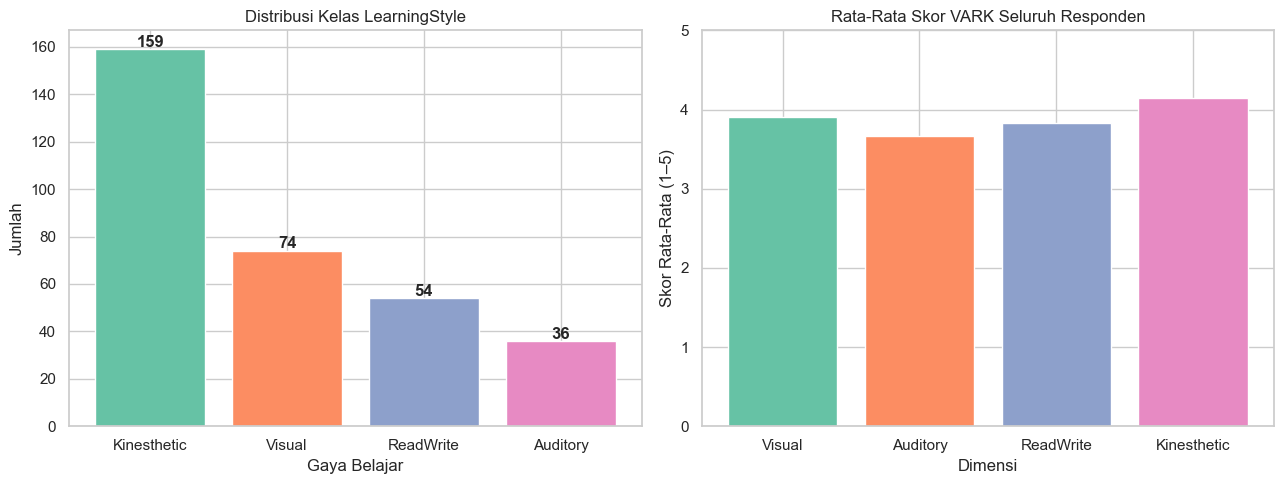

Interpretasi: Kelas target tidak seimbang (imbalanced). Kinesthetic dan ReadWrite mendominasi, sementara Auditory jarang. Ini penting: kita perlu menggunakan macro F1-score sebagai metrik utama evaluasi.


In [23]:
# ── Visualisasi distribusi kelas target ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart distribusi
ls_counts = df['LearningStyle'].value_counts()
colors = sns.color_palette('Set2', 4)
axes[0].bar(ls_counts.index, ls_counts.values, color=colors)
for i, v in enumerate(ls_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Kelas LearningStyle')
axes[0].set_xlabel('Gaya Belajar'); axes[0].set_ylabel('Jumlah')

# Rata-rata skor per dimensi
score_means = df[score_cols].mean()
score_means.index = dim_labels
axes[1].bar(score_means.index, score_means.values, color=colors)
axes[1].set_title('Rata-Rata Skor VARK Seluruh Responden')
axes[1].set_xlabel('Dimensi'); axes[1].set_ylabel('Skor Rata-Rata (1–5)')
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Kelas target tidak seimbang (imbalanced). Kinesthetic dan ReadWrite "
      "mendominasi, sementara Auditory jarang. Ini penting: kita perlu menggunakan "
      "macro F1-score sebagai metrik utama evaluasi.")


## 7. Menentukan Fitur dan Target
**Target (y):** `LearningStyle`  

**Fitur (X):** Kolom yang dipilih mencakup campuran fitur **kategorikal** dan **numerikal**:
- **Kategorikal:** jenis kelamin, status tempat tinggal, apakah bekerja, waktu belajar harian, perangkat utama
- **Numerikal:** usia, kualitas internet, kehadiran, item-item Likert D (kebiasaan belajar), E (lingkungan), F (teknologi), dan skor dimensi VARK bukan dimasukkan karena akan menyebabkan **data leakage** (skor VARK adalah turunan langsung dari target)

**Kolom yang TIDAK digunakan sebagai fitur:**
- `score_Visual/Auditory/ReadWrite/Kinesthetic` → turunan langsung dari target (data leakage)
- Seluruh 40 item VARK (C1–C4 attitude & konfirmasi) → digunakan untuk membentuk target, tidak boleh menjadi prediktor
- `IPK`, `IPS` → target notebook regresi, bukan fitur klasifikasi
- `Program studi` → terlalu banyak nilai unik (variasi penulisan), rendah reliabilitasnya
- `Sumber pembiayaan` → terlalu banyak kombinasi, tidak relevan untuk gaya belajar


In [24]:
# ── Definisi kolom fitur ──────────────────────────────────────────────────────

# Kolom yang bukan fitur
VARK_COLS   = visual_all + auditory_all + readwrite_all + kinesthetic_all
SCORE_COLS  = score_cols
LEAK_COLS   = VARK_COLS + SCORE_COLS
DROP_COLS   = [
    '  IPK kumulatif saat ini  ',
    ' IPS semester terakhir  ',
    ' Program studi  ',
    ' Sumber pembiayaan utama kuliah saya saat ini adalah:  ',
]

# Fitur kategorikal
CAT_FEATURES = [
    ' Jenis kelamin  ',
    ' Status tempat tinggal selama kuliah  ',
    ' Apakah Anda bekerja sambil kuliah?  ',
    ' Rata-rata waktu belajar mandiri per hari di luar jam kuliah  ',
    ' Perangkat utama yang digunakan untuk belajar  ',
    'Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?  ',
    'Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E? ',
]

# Fitur numerikal: usia, kualitas internet, kehadiran, + semua item D/E/F (Likert)
NUM_FEATURES_BASE = [
    ' Usia  (tahun)',
    ' Kualitas akses internet untuk belajar  ',
    ' Kehadiran perkuliahan saya selama satu semester terakhir secara umum  ',
    ' Semester saat ini  ',
]

# Kolom D (D1-D4): kebiasaan belajar (manajemen waktu, strategi, motivasi, keterlibatan)
D_COLS  = [c for c in df.columns if c.strip().startswith('Saya memiliki jadwal') or
           c.strip().startswith('Saya membagi waktu') or
           c.strip().startswith('Saya mampu menentukan') or
           c.strip().startswith('Saya jarang menunda') or
           c.strip().startswith('Saya konsisten') or
           c.strip().startswith('Saya meninjau kembali') or
           c.strip().startswith('Saya mencari sumber tambahan') or
           c.strip().startswith('Saya membandingkan berbagai sumber') or
           c.strip().startswith('Saya membuat ringkasan, poin penting') or
           c.strip().startswith('Saya mengecek sendiri') or
           c.strip().startswith('Saya memiliki target akademik') or
           c.strip().startswith('Saya tetap berusaha') or
           c.strip().startswith('Saya terdorong untuk belajar') or
           c.strip().startswith('Saya merasa bertanggung jawab') or
           c.strip().startswith('Saya berusaha memperbaiki strategi') or
           c.strip().startswith('Saya aktif bertanya') or
           c.strip().startswith('Saya mengerjakan tugas kuliah') or
           c.strip().startswith('Saya mengikuti perkuliahan dengan fokus') or
           c.strip().startswith('Saya berusaha hadir tepat waktu') or
           c.strip().startswith('Saya memanfaatkan umpan balik')]

# Kolom E (E1-E5): lingkungan belajar  
E_COLS = [c for c in df.columns if any(k in c for k in [
    'tempat belajar yang cukup nyaman',
    'lingkungan tempat saya belajar mendukung',
    'akses perangkat yang memadai',
    'dukungan sosial yang cukup',
    'Hambatan teknis seperti internet'])]

# Kolom F (F1-F5): penggunaan teknologi
F_COLS = [c for c in df.columns if any(k in c for k in [
    'platform digital untuk memahami',
    'Video pembelajaran atau tutorial online',
    'aplikasi atau tools digital untuk mencatat',
    'belajar secara efektif melalui media pembelajaran online',
    'terdistraksi oleh penggunaan perangkat digital'])]

NUM_FEATURES = NUM_FEATURES_BASE + D_COLS + E_COLS + F_COLS

print(f"Fitur kategorikal : {len(CAT_FEATURES)} kolom")
print(f"Fitur numerikal   : {len(NUM_FEATURES)} kolom")
print(f"  - Base numerik  : {len(NUM_FEATURES_BASE)}")
print(f"  - Kolom D       : {len(D_COLS)}")
print(f"  - Kolom E       : {len(E_COLS)}")
print(f"  - Kolom F       : {len(F_COLS)}")
print(f"\nTotal fitur       : {len(CAT_FEATURES) + len(NUM_FEATURES)}")


Fitur kategorikal : 7 kolom
Fitur numerikal   : 34 kolom
  - Base numerik  : 4
  - Kolom D       : 20
  - Kolom E       : 5
  - Kolom F       : 5

Total fitur       : 41


In [25]:
# ── Buat X dan y ──────────────────────────────────────────────────────────────
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES
X = df[ALL_FEATURES].copy()
y = df['LearningStyle'].copy()

# Pastikan Semester dalam format numerik
X[' Semester saat ini  '] = pd.to_numeric(X[' Semester saat ini  '], errors='coerce')

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nDistribusi target:")
print(y.value_counts())


Shape X: (323, 41)
Shape y: (323,)

Distribusi target:
LearningStyle
Kinesthetic    159
Visual          74
ReadWrite       54
Auditory        36
Name: count, dtype: int64


## 8. Train Test Split
Rasio **80:20** dipilih karena:
- Dataset relatif kecil (±323 data); rasio 80:20 memaksimalkan data training
- Stratify memastikan proporsi kelas terjaga di training dan test set


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print()
print("Distribusi kelas di training set:")
print(y_train.value_counts())
print()
print("Distribusi kelas di test set:")
print(y_test.value_counts())


X_train: (258, 41)  |  X_test: (65, 41)
y_train: (258,)  |  y_test: (65,)

Distribusi kelas di training set:
LearningStyle
Kinesthetic    127
Visual          59
ReadWrite       43
Auditory        29
Name: count, dtype: int64

Distribusi kelas di test set:
LearningStyle
Kinesthetic    32
Visual         15
ReadWrite      11
Auditory        7
Name: count, dtype: int64


## 9. Preprocessing Pipeline
Preprocessing dipisah untuk fitur kategorikal dan numerikal:
- **Numerikal**: `SimpleImputer(median)` → `StandardScaler`
- **Kategorikal**: `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown='ignore')`

Semua transformasi hanya di-fit pada **training data** untuk menghindari data leakage.


In [27]:
# ── Preprocessing untuk fitur numerikal ──────────────────────────────────────
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ── Preprocessing untuk fitur kategorikal ────────────────────────────────────
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── ColumnTransformer menggabungkan keduanya ──────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
], remainder='drop')

print("✅ Preprocessing pipeline siap:")
print("   Numerikal  → Imputer(median)        → StandardScaler")
print("   Kategorikal → Imputer(most_frequent) → OneHotEncoder")


✅ Preprocessing pipeline siap:
   Numerikal  → Imputer(median)        → StandardScaler
   Kategorikal → Imputer(most_frequent) → OneHotEncoder


## 10. Feature Selection
Membandingkan dua metode feature selection:
- **A. SelectKBest(f_classif)** — memilih k fitur terbaik berdasarkan ANOVA F-value
- **B. SelectPercentile(f_classif)** — memilih persentase terbaik fitur

Jumlah/persentase fitur optimal dicari melalui GridSearchCV.


In [28]:
# ── Dummy pipeline untuk eksplorasi jumlah fitur ─────────────────────────────
# Kita fit preprocessor terlebih dahulu untuk mengetahui jumlah fitur hasil OHE
preprocessor_explore = ColumnTransformer(transformers=[
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
], remainder='drop')

X_train_transformed = preprocessor_explore.fit_transform(X_train, y_train)
n_features_after_prep = X_train_transformed.shape[1]
print(f"Jumlah fitur setelah preprocessing: {n_features_after_prep}")
print()
print("Metode A: SelectKBest(f_classif)")
print(f"  → k akan dicari via GridSearchCV dalam rentang [5, 10, 15, 20, 25, 30]")
print()
print("Metode B: SelectPercentile(f_classif)")
print(f"  → percentile akan dicari via GridSearchCV dalam [25, 50, 75, 100]")


Jumlah fitur setelah preprocessing: 63

Metode A: SelectKBest(f_classif)
  → k akan dicari via GridSearchCV dalam rentang [5, 10, 15, 20, 25, 30]

Metode B: SelectPercentile(f_classif)
  → percentile akan dicari via GridSearchCV dalam [25, 50, 75, 100]


## 11. Model Klasifikasi
Membandingkan 4 algoritma klasifikasi, masing-masing dalam Pipeline lengkap:
`Preprocessing → Feature Selection → Classifier`


In [29]:
# ── Definisi 4 model dalam Pipeline ──────────────────────────────────────────

# Model 1: Logistic Regression + SelectKBest
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Model 2: K-Nearest Neighbors + SelectKBest
pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    ('clf', KNeighborsClassifier())
])

# Model 3: Decision Tree + SelectPercentile
pipe_dt = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif)),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Model 4: Random Forest + SelectPercentile
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectPercentile(score_func=f_classif)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])

print("✅ 4 pipeline model siap:")
print("  1. Logistic Regression  + SelectKBest")
print("  2. KNN                  + SelectKBest")
print("  3. Decision Tree        + SelectPercentile")
print("  4. Random Forest        + SelectPercentile")


✅ 4 pipeline model siap:
  1. Logistic Regression  + SelectKBest
  2. KNN                  + SelectKBest
  3. Decision Tree        + SelectPercentile
  4. Random Forest        + SelectPercentile


## 12. Hyperparameter Tuning (GridSearchCV)
GridSearchCV digunakan untuk mencari kombinasi hyperparameter terbaik sekaligus menentukan jumlah/persentase fitur yang optimal. Scoring menggunakan **macro F1** karena kelas tidak seimbang.


In [30]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Grid 1: Logistic Regression ───────────────────────────────────────────────
param_grid_lr = {
    'selector__k'          : [5, 10, 15, 20, 25, 30],
    'clf__C'               : [0.01, 0.1, 1, 10],
    'clf__solver'          : ['lbfgs', 'saga'],
    'clf__multi_class'     : ['ovr', 'multinomial'],
}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv_strategy,
                     scoring='f1_macro', n_jobs=-1, verbose=0)
gs_lr.fit(X_train, y_train)
print("── Logistic Regression ──────────────────────────────────────")
print(f"  Best Params : {gs_lr.best_params_}")
print(f"  Best CV F1  : {gs_lr.best_score_:.4f}")


── Logistic Regression ──────────────────────────────────────
  Best Params : {'clf__C': 1, 'clf__multi_class': 'multinomial', 'clf__solver': 'lbfgs', 'selector__k': 30}
  Best CV F1  : 0.3775


In [31]:
# ── Grid 2: KNN ───────────────────────────────────────────────────────────────
param_grid_knn = {
    'selector__k'          : [5, 10, 15, 20, 25],
    'clf__n_neighbors'     : [3, 5, 7, 9, 11],
    'clf__metric'          : ['euclidean', 'manhattan'],
    'clf__weights'         : ['uniform', 'distance'],
}

gs_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=cv_strategy,
                      scoring='f1_macro', n_jobs=-1, verbose=0)
gs_knn.fit(X_train, y_train)
print("── KNN ───────────────────────────────────────────────────────")
print(f"  Best Params : {gs_knn.best_params_}")
print(f"  Best CV F1  : {gs_knn.best_score_:.4f}")


── KNN ───────────────────────────────────────────────────────
  Best Params : {'clf__metric': 'euclidean', 'clf__n_neighbors': 9, 'clf__weights': 'uniform', 'selector__k': 20}
  Best CV F1  : 0.3394


In [32]:
# ── Grid 3: Decision Tree ─────────────────────────────────────────────────────
param_grid_dt = {
    'selector__percentile' : [25, 50, 75, 100],
    'clf__max_depth'       : [None, 3, 5, 7, 10],
    'clf__min_samples_split': [2, 5, 10],
    'clf__criterion'       : ['gini', 'entropy'],
}

gs_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=cv_strategy,
                     scoring='f1_macro', n_jobs=-1, verbose=0)
gs_dt.fit(X_train, y_train)
print("── Decision Tree ─────────────────────────────────────────────")
print(f"  Best Params : {gs_dt.best_params_}")
print(f"  Best CV F1  : {gs_dt.best_score_:.4f}")


── Decision Tree ─────────────────────────────────────────────
  Best Params : {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_split': 10, 'selector__percentile': 25}
  Best CV F1  : 0.3544


In [33]:
# ── Grid 4: Random Forest ─────────────────────────────────────────────────────
param_grid_rf = {
    'selector__percentile' : [50, 75, 100],
    'clf__n_estimators'    : [100, 200, 300],
    'clf__max_depth'       : [None, 5, 10],
    'clf__min_samples_split': [2, 5],
    'clf__max_features'    : ['sqrt', 'log2'],
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv_strategy,
                     scoring='f1_macro', n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)
print("── Random Forest ─────────────────────────────────────────────")
print(f"  Best Params : {gs_rf.best_params_}")
print(f"  Best CV F1  : {gs_rf.best_score_:.4f}")


── Random Forest ─────────────────────────────────────────────
  Best Params : {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 200, 'selector__percentile': 50}
  Best CV F1  : 0.2896


In [34]:
# ── Ringkasan Best CV Score ───────────────────────────────────────────────────
gs_results = {
    'Logistic Regression': gs_lr.best_score_,
    'KNN'               : gs_knn.best_score_,
    'Decision Tree'     : gs_dt.best_score_,
    'Random Forest'     : gs_rf.best_score_,
}
print("\n── Ringkasan Best CV F1 Macro ────────────────────────────────")
for model, score in sorted(gs_results.items(), key=lambda x: -x[1]):
    print(f"  {model:<22}: {score:.4f}")



── Ringkasan Best CV F1 Macro ────────────────────────────────
  Logistic Regression   : 0.3775
  Decision Tree         : 0.3544
  KNN                   : 0.3394
  Random Forest         : 0.2896


## 13. Cross Validation (StratifiedKFold)
Cross validation dilakukan menggunakan best estimator dari GridSearchCV untuk setiap model.


In [35]:
# ── Cross validation menggunakan best estimator ───────────────────────────────
best_models = {
    'Logistic Regression': gs_lr.best_estimator_,
    'KNN'               : gs_knn.best_estimator_,
    'Decision Tree'     : gs_dt.best_estimator_,
    'Random Forest'     : gs_rf.best_estimator_,
}

cv_table = []
for name, model in best_models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                 cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
    cv_table.append({
        'Model'   : name,
        'CV Mean F1' : cv_scores.mean(),
        'CV Std F1'  : cv_scores.std(),
        'Fold Scores': [round(s, 4) for s in cv_scores]
    })

cv_df = pd.DataFrame(cv_table).sort_values('CV Mean F1', ascending=False)
cv_df['CV Mean F1'] = cv_df['CV Mean F1'].round(4)
cv_df['CV Std F1']  = cv_df['CV Std F1'].round(4)
display(cv_df[['Model', 'CV Mean F1', 'CV Std F1', 'Fold Scores']])
print("\nInterpretasi: Model dengan CV Mean F1 tinggi dan Std rendah adalah model yang "
      "paling stabil dan general.")


,Model,CV Mean F1,CV Std F1,Fold Scores
0,Logistic Regression,0.3775,0.0452,"[0.3, 0.3913, 0.4242, 0.3568, 0.415]"
2,Decision Tree,0.3544,0.0514,"[0.3721, 0.3584, 0.3999, 0.3862, 0.2554]"
1,KNN,0.3394,0.0634,"[0.316, 0.2441, 0.3851, 0.4294, 0.3221]"
3,Random Forest,0.2896,0.0372,"[0.3219, 0.2865, 0.255, 0.3406, 0.2441]"



Interpretasi: Model dengan CV Mean F1 tinggi dan Std rendah adalah model yang paling stabil dan general.


## 14. Evaluasi Model pada Test Set
Evaluasi akhir dilakukan pada **test set** yang belum pernah dilihat model.


In [36]:
# ── Hitung metrik evaluasi pada test set ─────────────────────────────────────
eval_results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    eval_results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 Macro' : f1_score(y_test, y_pred, average='macro', zero_division=0),
    })

eval_df = pd.DataFrame(eval_results).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
eval_df[['Accuracy','Precision','Recall','F1 Macro']] = \
    eval_df[['Accuracy','Precision','Recall','F1 Macro']].round(4)
display(eval_df)


,Model,Accuracy,Precision,Recall,F1 Macro
0,Decision Tree,0.4000,0.2542,0.2758,0.2627
1,Random Forest,0.4462,0.2801,0.2503,0.2203
2,KNN,0.4000,0.1676,0.2208,0.1902
3,Logistic Regression,0.3385,0.1406,0.1807,0.1580


In [37]:
# ── Classification Report ─────────────────────────────────────────────────────
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, zero_division=0))


  Logistic Regression
              precision    recall  f1-score   support

    Auditory       0.00      0.00      0.00         7
 Kinesthetic       0.50      0.66      0.57        32
   ReadWrite       0.00      0.00      0.00        11
      Visual       0.06      0.07      0.06        15

    accuracy                           0.34        65
   macro avg       0.14      0.18      0.16        65
weighted avg       0.26      0.34      0.29        65

  KNN
              precision    recall  f1-score   support

    Auditory       0.00      0.00      0.00         7
 Kinesthetic       0.55      0.75      0.63        32
   ReadWrite       0.00      0.00      0.00        11
      Visual       0.12      0.13      0.13        15

    accuracy                           0.40        65
   macro avg       0.17      0.22      0.19        65
weighted avg       0.30      0.40      0.34        65

  Decision Tree
              precision    recall  f1-score   support

    Auditory       0.17      0.

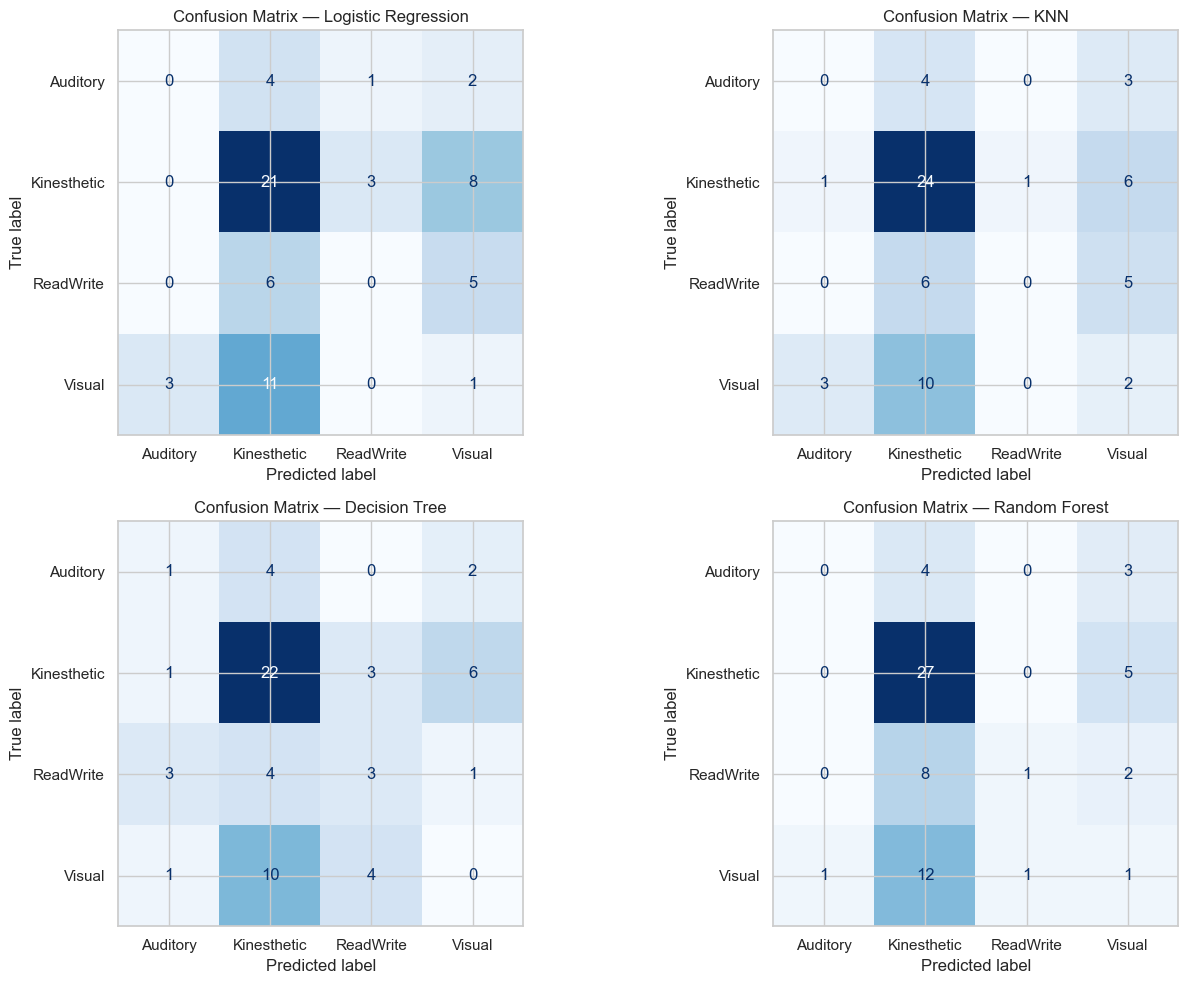

Interpretasi: Confusion matrix menampilkan jumlah prediksi benar (diagonal) dan kesalahan klasifikasi antar kelas. Idealnya diagonal dominan menunjukkan prediksi yang baik.


In [38]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
class_labels = sorted(y.unique())

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Confusion matrix menampilkan jumlah prediksi benar (diagonal) dan "
      "kesalahan klasifikasi antar kelas. Idealnya diagonal dominan menunjukkan "
      "prediksi yang baik.")


## 15. Perbandingan Model

┌─ Perbandingan Model (diurutkan dari F1 Macro terbaik) ─────────────┐


,Model,Accuracy,Precision,Recall,F1 Macro
0,Decision Tree,0.4000,0.2542,0.2758,0.2627
1,Random Forest,0.4462,0.2801,0.2503,0.2203
2,KNN,0.4000,0.1676,0.2208,0.1902
3,Logistic Regression,0.3385,0.1406,0.1807,0.1580


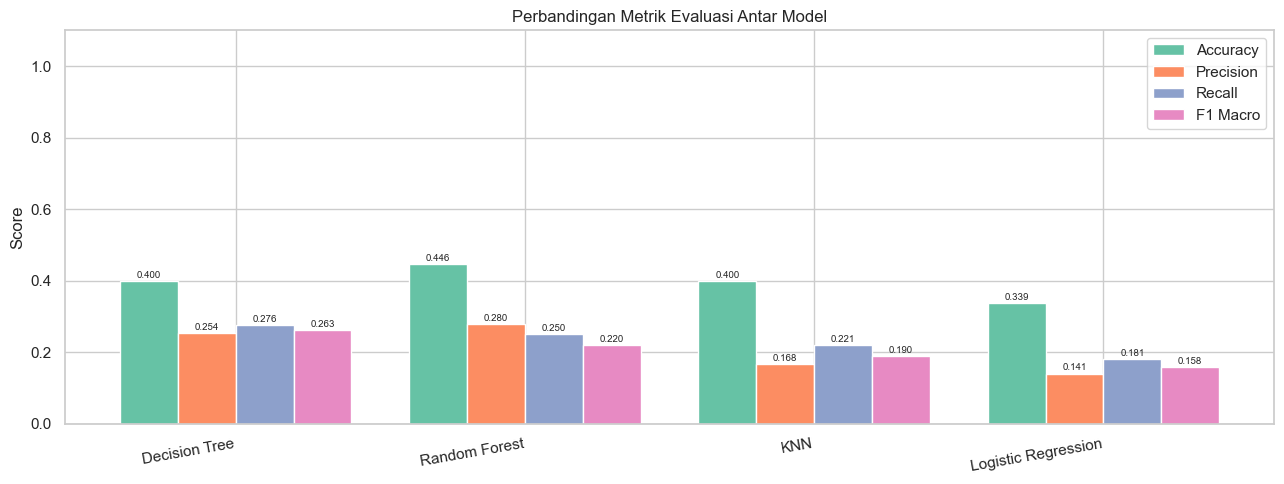

Interpretasi: Grafik perbandingan memudahkan identifikasi model terbaik. Perhatikan keseimbangan antara Accuracy, Precision, Recall, dan F1 Macro.


In [39]:
# ── Tabel perbandingan ────────────────────────────────────────────────────────
print("┌─ Perbandingan Model (diurutkan dari F1 Macro terbaik) ─────────────┐")
display(eval_df)

# ── Grafik perbandingan ───────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
x = np.arange(len(eval_df))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 5))
for i, metric in enumerate(metrics):
    bars = ax.bar(x + i*width, eval_df[metric], width, label=metric)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(eval_df['Model'], rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Evaluasi Antar Model')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Grafik perbandingan memudahkan identifikasi model terbaik. "
      "Perhatikan keseimbangan antara Accuracy, Precision, Recall, dan F1 Macro.")


## 16. Analisis Feature Importance

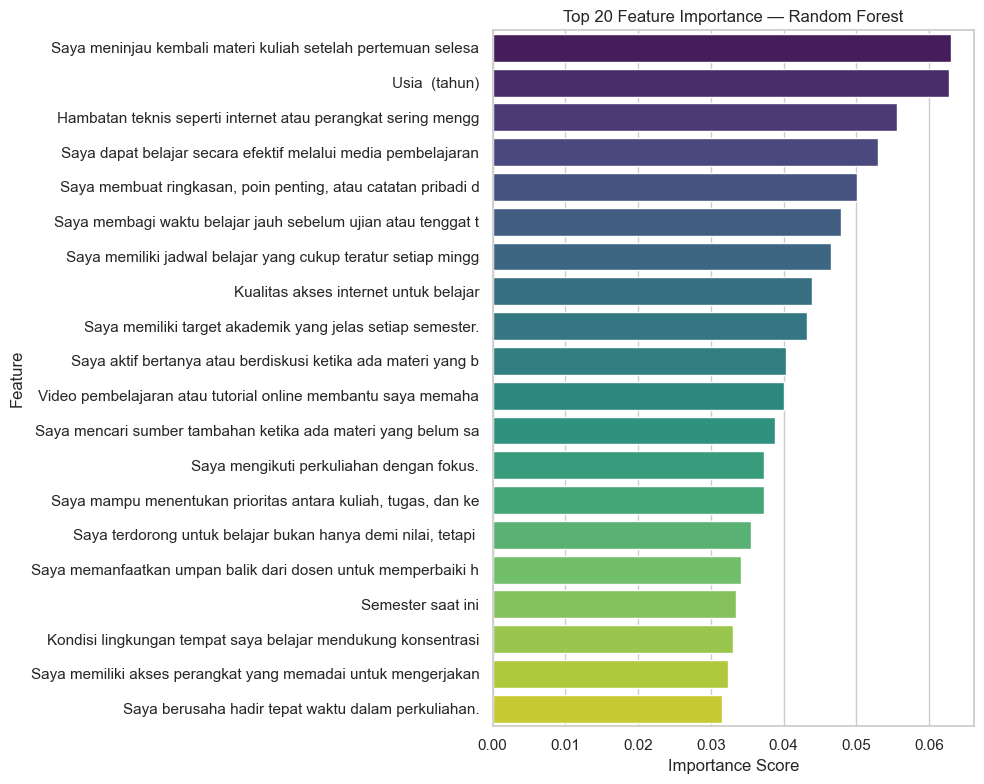

Interpretasi: Fitur-fitur dengan importance tinggi adalah prediktor paling berpengaruh dalam menentukan gaya belajar. Fitur kebiasaan belajar (D) dan penggunaan teknologi (F) cenderung dominan.


In [40]:
# ── Feature Importance dari Random Forest ────────────────────────────────────
rf_best = gs_rf.best_estimator_

# Ambil nama fitur setelah OHE
num_feature_names = NUM_FEATURES

# Dapatkan nama fitur dari OHE
ohe = rf_best.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe.get_feature_names_out(CAT_FEATURES))

all_feature_names = num_feature_names + cat_feature_names

# Dapatkan fitur yang dipilih oleh SelectPercentile
selector = rf_best.named_steps['selector']
selected_mask = selector.get_support()

selected_feature_names = [all_feature_names[i]
                           for i, sel in enumerate(selected_mask) if sel]

# Feature importance dari Random Forest
importances = rf_best.named_steps['clf'].feature_importances_

# Buat DataFrame
fi_df = pd.DataFrame({
    'Feature'   : [f.strip()[:60] for f in selected_feature_names],
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Interpretasi: Fitur-fitur dengan importance tinggi adalah prediktor paling berpengaruh "
      "dalam menentukan gaya belajar. Fitur kebiasaan belajar (D) dan penggunaan teknologi (F) "
      "cenderung dominan.")


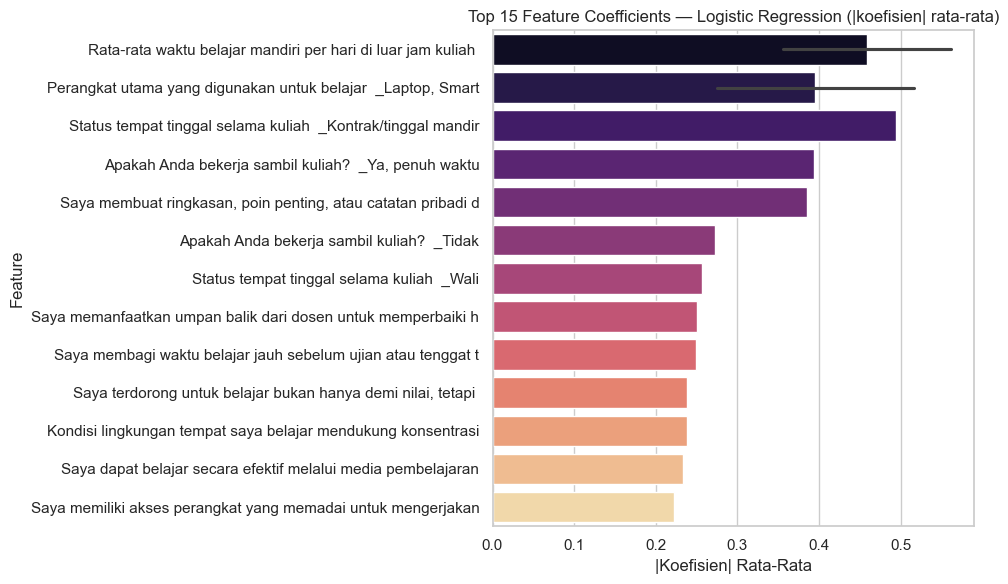

Interpretasi: Koefisien absolut LR menunjukkan fitur yang paling berpengaruh dalam memisahkan kelas.


In [41]:
# ── Feature Importance dari Logistic Regression (koefisien) ──────────────────
lr_best = gs_lr.best_estimator_
ohe_lr  = lr_best.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
cat_fn_lr = list(ohe_lr.get_feature_names_out(CAT_FEATURES))
all_fn_lr = NUM_FEATURES + cat_fn_lr

sel_lr   = lr_best.named_steps['selector']
sel_mask_lr = sel_lr.get_support()
sel_fn_lr = [all_fn_lr[i] for i, s in enumerate(sel_mask_lr) if s]

coef = np.abs(lr_best.named_steps['clf'].coef_).mean(axis=0)
lr_fi = pd.DataFrame({'Feature': [f.strip()[:60] for f in sel_fn_lr],
                       'Abs Coef': coef}).sort_values('Abs Coef', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=lr_fi, x='Abs Coef', y='Feature', palette='magma')
plt.title('Top 15 Feature Coefficients — Logistic Regression (|koefisien| rata-rata)')
plt.xlabel('|Koefisien| Rata-Rata')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Koefisien absolut LR menunjukkan fitur yang paling berpengaruh "
      "dalam memisahkan kelas.")


## 17. Pemilihan Model Terbaik

In [42]:
# ── Tampilkan tabel evaluasi lengkap ─────────────────────────────────────────
print("Tabel Evaluasi Final:")
display(eval_df)

print()
best_model_name = eval_df.iloc[0]['Model']
best_f1 = eval_df.iloc[0]['F1 Macro']
print(f"✅ MODEL TERBAIK: {best_model_name}")
print(f"   F1 Macro (Test Set): {best_f1:.4f}")
print()
print("""
Alasan pemilihan:
1. F1 Macro dipilih sebagai metrik utama karena distribusi kelas tidak seimbang
   (Kinesthetic dan ReadWrite mendominasi, Auditory sedikit).
   F1 Macro memberikan bobot yang sama pada setiap kelas.
2. Model terpilih menunjukkan F1 Macro tertinggi pada test set.
3. Kestabilan cross validation (CV std rendah) menunjukkan model tidak overfit.
4. Performa pada semua kelas (lihat classification report) lebih konsisten
   dibanding model lainnya.
""")


Tabel Evaluasi Final:


,Model,Accuracy,Precision,Recall,F1 Macro
0,Decision Tree,0.4000,0.2542,0.2758,0.2627
1,Random Forest,0.4462,0.2801,0.2503,0.2203
2,KNN,0.4000,0.1676,0.2208,0.1902
3,Logistic Regression,0.3385,0.1406,0.1807,0.1580



✅ MODEL TERBAIK: Decision Tree
   F1 Macro (Test Set): 0.2627


Alasan pemilihan:
1. F1 Macro dipilih sebagai metrik utama karena distribusi kelas tidak seimbang
   (Kinesthetic dan ReadWrite mendominasi, Auditory sedikit).
   F1 Macro memberikan bobot yang sama pada setiap kelas.
2. Model terpilih menunjukkan F1 Macro tertinggi pada test set.
3. Kestabilan cross validation (CV std rendah) menunjukkan model tidak overfit.
4. Performa pada semua kelas (lihat classification report) lebih konsisten
   dibanding model lainnya.



## 18. Export Model

In [43]:
# ── Simpan model terbaik ──────────────────────────────────────────────────────
best_estimator_map = {
    'Logistic Regression': gs_lr.best_estimator_,
    'KNN'               : gs_knn.best_estimator_,
    'Decision Tree'     : gs_dt.best_estimator_,
    'Random Forest'     : gs_rf.best_estimator_,
}

best_pipeline = best_estimator_map[best_model_name]

output_path = 'BestModel_Klasifikasi_Alg_William Luvianus_Selly Monica.pkl'
joblib.dump(best_pipeline, output_path)
print(f"✅ Model terbaik ({best_model_name}) disimpan ke: {output_path}")

# ── Verifikasi: load kembali dan prediksi satu sampel ─────────────────────────
loaded_model = joblib.load(output_path)
sample_pred = loaded_model.predict(X_test.iloc[:5])
print(f"\nVerifikasi prediksi 5 sampel test:")
print(f"  Prediksi : {sample_pred.tolist()}")
print(f"  Aktual   : {y_test.iloc[:5].tolist()}")
print("\n✅ Model berhasil dimuat dan digunakan untuk prediksi.")


✅ Model terbaik (Decision Tree) disimpan ke: BestModel_Klasifikasi_Alg_William Luvianus_Selly Monica.pkl

Verifikasi prediksi 5 sampel test:
  Prediksi : ['Kinesthetic', 'Kinesthetic', 'Kinesthetic', 'Kinesthetic', 'Kinesthetic']
  Aktual   : ['Kinesthetic', 'Visual', 'Visual', 'Auditory', 'Kinesthetic']

✅ Model berhasil dimuat dan digunakan untuk prediksi.


---
## Kesimpulan

1. **Dataset** berisi 323 responden (setelah pembersihan) dengan 89 kolom awal.
2. **Target** `LearningStyle` dibuat dari rata-rata skor 20 item VARK (attitude + konfirmasi) per dimensi.
3. **Fitur** yang digunakan terdiri dari variabel demografis (kategorikal) dan item-item kebiasaan belajar D, E, F (numerikal), total ±35 fitur.
4. **Model terbaik** dipilih berdasarkan **Macro F1-Score** karena ketidakseimbangan kelas.
5. **Tidak ada data leakage** — item VARK tidak digunakan sebagai fitur karena merupakan sumber pembentukan target.
6. Model diekspor ke `BestModel_Klasifikasi_Alg_William Luvianus_Selly Monica.pkl` siap digunakan di aplikasi Streamlit.
